In [1]:
from curves import FourierCurve
from base_curve import CurveTester, ArclenParameterize, LearnableCurve
import torch
import torch.nn as nn
from torchquad.integration.simpson import Simpson
from tqdm import trange

import torchquad
torchquad.set_up_backend('torch')

from loguru import logger
logger.remove()

torch.set_default_device('cuda')

2026-01-26 11:03:48.242 | INFO     | torchquad.utils.enable_cuda:enable_cuda:17 - PyTorch VERSION: 2.9.1+cu128
2026-01-26 11:03:48.244 | INFO     | torchquad.utils.enable_cuda:enable_cuda:18 - CUDNN VERSION: 91002
2026-01-26 11:03:48.268 | INFO     | torchquad.utils.enable_cuda:enable_cuda:19 - Number of CUDA Devices: 1
2026-01-26 11:03:48.270 | INFO     | torchquad.utils.enable_cuda:enable_cuda:20 - Active CUDA Device: GPU0
2026-01-26 11:03:48.271 | INFO     | torchquad.utils.set_precision:set_precision:54 - Setting Torch's default dtype to float32 and device to CUDA.


In [2]:
fourier = FourierCurve( 
    1, 
    torch.linspace( 0.1, 12 * torch.pi, 48 ), 
    ( 0.0, torch.tensor([0, 0, 0]), 0 ),
    ( 1.0, torch.tensor([0, 0, 0]), 0 ),
    ( 0.0, torch.tensor([0, 0, 0]), 2 ),
    ( 1.0, torch.tensor([0, 0, 0]), 2 ),
)


In [3]:
print( fourier(1) - fourier(0) )
print( fourier.curvature(0), fourier.curvature(1) )

tensor([[ 1.3970e-08,  0.0000e+00, -2.4214e-08]], device='cuda:0',
       grad_fn=<SubBackward0>)
tensor([1.8526e-06], device='cuda:0', grad_fn=<LinalgVectorNormBackward0>) tensor([1.2439e-05], device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)


In [4]:
tester = CurveTester(
    fourier, 
    torch.tensor([ [0, 0, 0], [0, 0, -1/6], [0, 0, 0], [0, 0, 1/120] ]),
    torch.tensor([0.1, 10, 50, 100])
)


In [5]:
STEPS = 25_000

bar = trange(0, STEPS)
bar_iter = iter(bar)

def callback(step, loss, crve : ArclenParameterize):
    next(bar_iter)
    bar.set_postfix_str(f"Loss: {loss}")
    crve._arc_dirty = True

tester.optimize( steps=STEPS, callback=callback )

  0%|          | 0/25000 [00:00<?, ?it/s]/home/bobby/CS/quantum/.venv/lib/python3.11/site-packages/torchquad/integration/simpson.py:75: UserWarning: N per dimension cannot be even due to necessary subdivisions. N per dim will now be changed to the next lower integer, i.e. 8192 -> 8191.
  warnings.warn(
100%|█████████▉| 24997/25000 [09:39<00:00, 44.42it/s, Loss: 0.41809287667274475]

/home/bobby/CS/quantum/.venv/lib/python3.11/site-packages/torch/utils/_device.py:103: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return func(*args, **kwargs)


[0.0, -0.16626077890396118, -0.0011426206910982728, 0.008396264165639877]


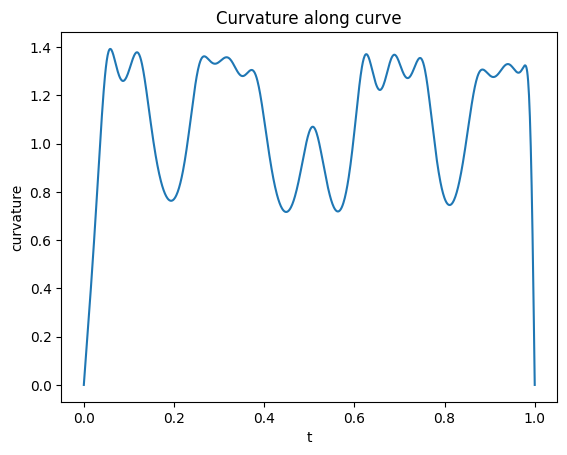

<Axes: title={'center': 'Curvature along curve'}, xlabel='t', ylabel='curvature'>

100%|█████████▉| 24997/25000 [09:50<00:00, 44.42it/s, Loss: 0.41809287667274475]

In [ ]:
print( tester.poly_z() )
tester.curve.plot_curvature()